## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [2]:
df = pd.read_csv('./programming.csv')

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [3]:
df.head(5)


,Date,Language,posts
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [4]:
df.tail()

,Date,Language,posts
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [5]:
df.shape

(1991, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [6]:
df.count()

Date        1991
Language    1991
posts       1991
dtype: int64

In [7]:
languages = df['Language'].unique()

In [8]:
post_count = {}
for language in languages:
    post_count[language] = df[df['Language'] == language]['posts'].sum()

In [9]:
print(post_count)

{'c#': np.int64(1423530), 'assembly': np.int64(34852), 'javascript': np.int64(2056510), 'c': np.int64(336042), 'python': np.int64(1496210), 'perl': np.int64(65286), 'c++': np.int64(684210), 'java': np.int64(1696403), 'delphi': np.int64(46212), 'ruby': np.int64(214582), 'php': np.int64(1361988), 'r': np.int64(356799), 'swift': np.int64(273055), 'go': np.int64(47499)}


In [10]:
post_df =  df.groupby('Language')['posts'].sum()
print(post_df)

Language
assembly        34852
c              336042
c#            1423530
c++            684210
delphi          46212
go              47499
java          1696403
javascript    2056510
perl            65286
php           1361988
python        1496210
r              356799
ruby           214582
swift          273055
Name: posts, dtype: int64


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [11]:
months_count =  df.groupby('Language').count()
print(months_count)

            Date  posts
Language               
assembly     144    144
c            144    144
c#           145    145
c++          144    144
delphi       144    144
go           129    129
java         144    144
javascript   144    144
perl         144    144
php          144    144
python       144    144
r            142    142
ruby         144    144
swift        135    135


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [12]:
df.Date = pd.to_datetime(df.Date)

In [13]:
print(df.head())


        Date    Language  posts
0 2008-07-01          c#      3
1 2008-08-01    assembly      8
2 2008-08-01  javascript    162
3 2008-08-01           c     85
4 2008-08-01      python    124


## Data Manipulation



In [14]:
reshaped_df = df.pivot( index = 'Date', columns = 'Language' , values = 'posts')
reshaped_df.fillna(0, inplace=True) 

Language,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
Date,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-09-01,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-10-01,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-11-01,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0


In [15]:
print(reshaped_df.head())

Language    assembly      c      c#    c++  delphi   go    java  javascript  \
Date                                                                          
2008-07-01       0.0    0.0     3.0    0.0     0.0  0.0     0.0         0.0   
2008-08-01       8.0   85.0   511.0  164.0    14.0  0.0   222.0       162.0   
2008-09-01      28.0  321.0  1649.0  755.0   105.0  0.0  1137.0       640.0   
2008-10-01      15.0  303.0  1989.0  811.0   112.0  0.0  1153.0       725.0   
2008-11-01      17.0  259.0  1730.0  735.0   141.0  0.0   958.0       579.0   

Language     perl    php  python    r   ruby  swift  
Date                                                 
2008-07-01    0.0    0.0     0.0  0.0    0.0    0.0  
2008-08-01   28.0  161.0   124.0  0.0   73.0    0.0  
2008-09-01  131.0  482.0   542.0  6.0  290.0    0.0  
2008-10-01  127.0  617.0   510.0  0.0  249.0    0.0  
2008-11-01   97.0  504.0   452.0  1.0  160.0    0.0  


In [16]:
print(reshaped_df.count())

Language
assembly      145
c             145
c#            145
c++           145
delphi        145
go            145
java          145
javascript    145
perl          145
php           145
python        145
r             145
ruby          145
swift         145
dtype: int64


In [17]:
reshaped_df.isna().values.any()

np.False_

## Data Visualisaton with with Matplotlib


In [18]:
x = df[df['Language'] =='java']['Date']
y = reshaped_df[reshaped_df['java'] !=0]['java']



In [19]:
# x = y['date']
print(list(y))


[222.0, 1137.0, 1153.0, 958.0, 832.0, 1150.0, 1208.0, 1440.0, 1534.0, 1819.0, 2115.0, 2263.0, 2193.0, 2264.0, 2505.0, 2763.0, 2690.0, 3728.0, 3582.0, 4448.0, 3889.0, 4177.0, 4290.0, 4522.0, 4712.0, 4723.0, 5033.0, 5603.0, 5682.0, 6546.0, 6876.0, 8482.0, 7903.0, 8576.0, 7926.0, 8172.0, 8703.0, 8348.0, 8577.0, 9665.0, 9227.0, 10164.0, 10981.0, 12425.0, 12070.0, 12214.0, 11142.0, 12274.0, 12275.0, 11635.0, 13517.0, 13632.0, 12451.0, 13753.0, 13757.0, 15971.0, 16310.0, 15359.0, 14003.0, 15263.0, 15122.0, 16330.0, 18816.0, 18846.0, 17536.0, 18767.0, 19378.0, 22109.0, 21020.0, 18088.0, 16016.0, 17466.0, 15837.0, 16820.0, 18010.0, 17956.0, 16470.0, 16639.0, 16827.0, 19850.0, 19890.0, 18605.0, 17919.0, 18761.0, 17139.0, 17003.0, 18603.0, 17836.0, 16610.0, 16691.0, 17900.0, 19972.0, 19551.0, 17104.0, 15962.0, 14991.0, 15226.0, 14726.0, 15388.0, 15695.0, 13887.0, 14621.0, 14613.0, 17366.0, 15987.0, 16395.0, 14658.0, 14191.0, 13784.0, 12800.0, 14051.0, 14242.0, 12023.0, 12391.0, 12084.0, 13617.0,

In [20]:
print(x)

8      2008-08-01
16     2008-09-01
25     2008-10-01
39     2008-11-01
51     2008-12-01
          ...    
1921   2020-03-01
1935   2020-04-01
1949   2020-05-01
1964   2020-06-01
1978   2020-07-01
Name: Date, Length: 144, dtype: datetime64[us]


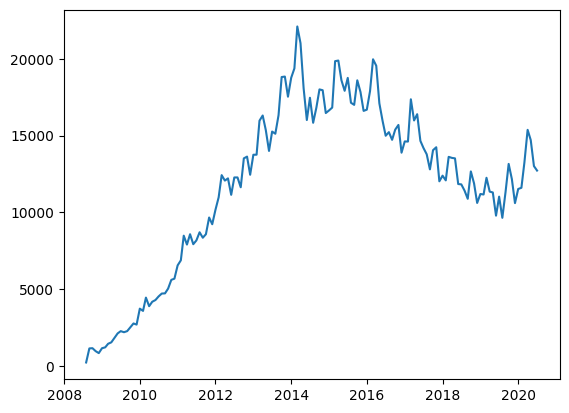

In [21]:
plt.plot(x,y)

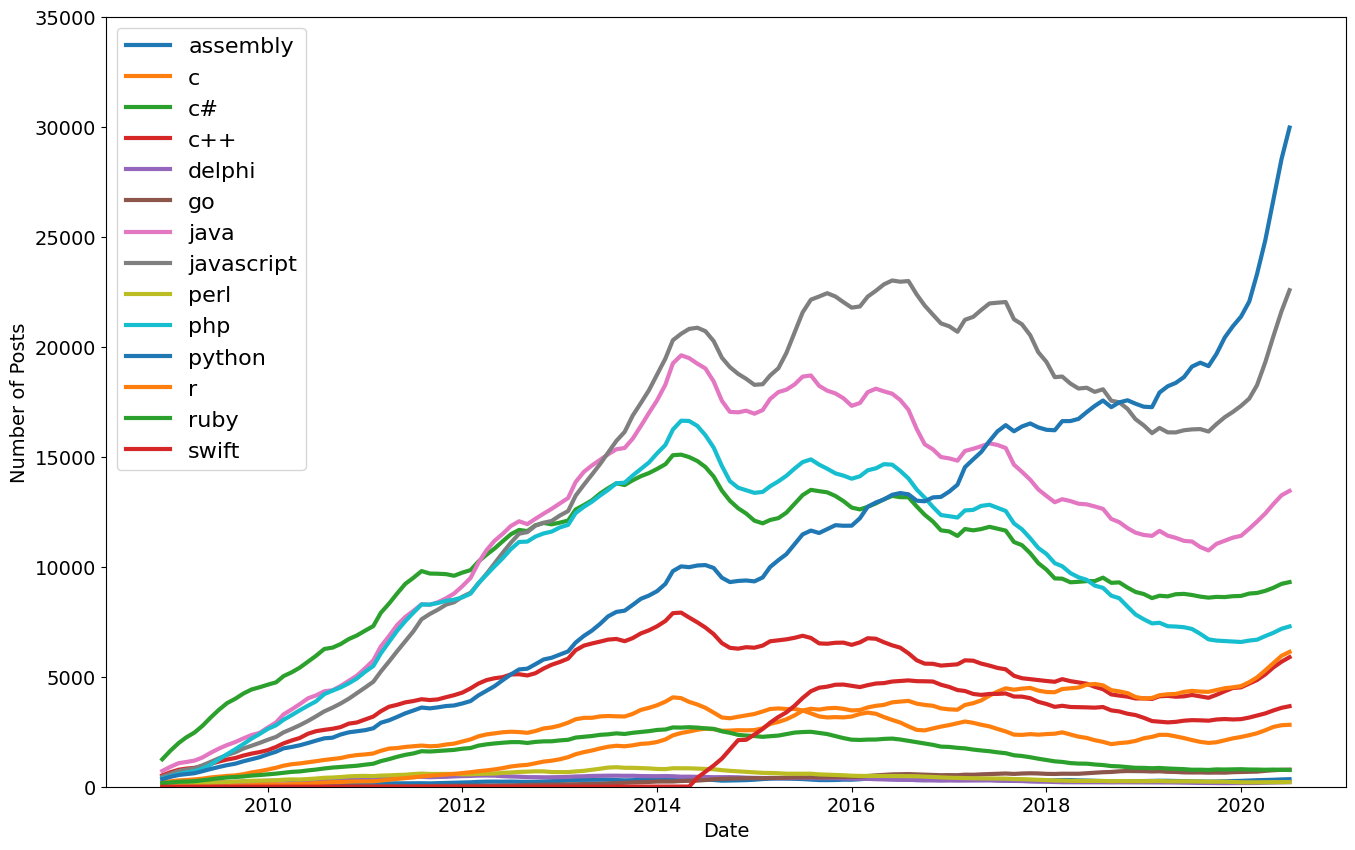

In [34]:
roll_df = reshaped_df.rolling(window=6).mean()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
for language in roll_df.columns:
    plt.plot(roll_df.index, roll_df[language] , linewidth=3, label=roll_df[language].name)

plt.legend(fontsize=16)

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 